In [1]:
import scanpy as sc
import squidpy as sq
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


In [2]:
outdir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/neighborhood_analysis/high_score_sen_cells_pt02/'

In [3]:
adata_sub = sc.read_h5ad('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/neighborhood_analysis/high_score_sen_cells_pt02/adata_zones_broad_celltypes_zones_highsen_pt02_neighbor.h5ad')

In [4]:
adata_sub

AnnData object with n_obs × n_vars = 270311 × 17931
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'celltype_proj_heps_pt02', 'celltype_proj_heps_pt02_cp'
    uns: 'celltype_proj_colors', 'celltype_proj_heps_pt02_cp_co_occurrence', 'celltype_proj_heps_pt02_cp_nhood_enrichment', 'clusters', 'hvg', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [ ]:
# Convert unique values in the 'celltype' column to a list
celltypes = adata_sub.obs['celltype_proj_heps_pt02_cp'].unique().tolist()
print(celltypes)

In [ ]:
sq.pl.nhood_enrichment(adata_sub, cluster_key="celltype_proj_heps_pt02_cp") #with match sen
#plt.savefig(outdir + 'enrich_mat_sub.pdf', bbox_inches='tight')


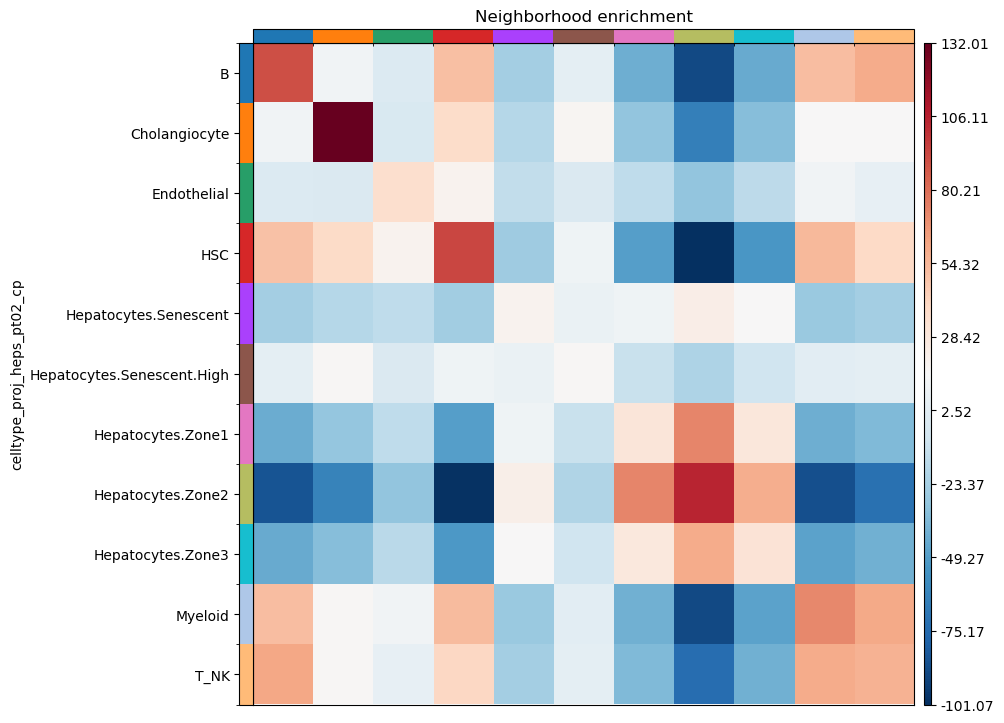

In [52]:
sq.pl.nhood_enrichment(
    adata_sub, 
    cluster_key="celltype_proj_heps_pt02_cp",
    cmap="RdBu_r"  # Red-Blue color scale
)
plt.savefig(outdir + 'enrich_mat_sub_white_mid.pdf', bbox_inches='tight')


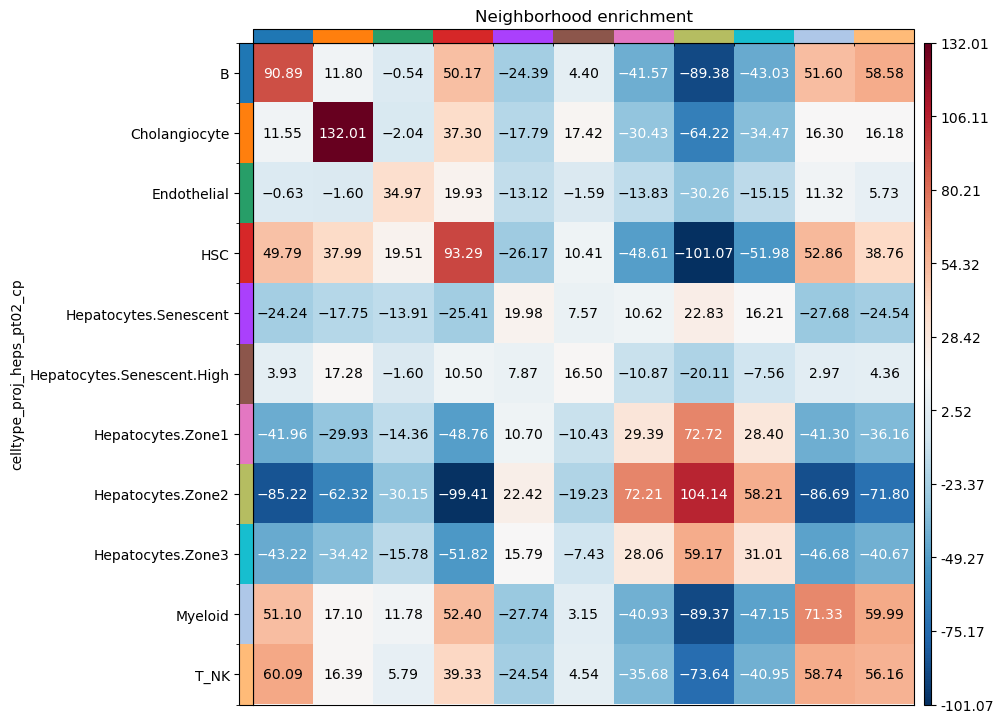

In [53]:
sq.pl.nhood_enrichment(
    adata_sub, 
    cluster_key="celltype_proj_heps_pt02_cp",
    cmap="RdBu_r",  # Red-Blue color scale
    annotate = True
)
plt.savefig(outdir + 'enrich_mat_sub_white_mid_anno.pdf', bbox_inches='tight')


In [ ]:
sq.pl.nhood_enrichment(
    adata_sub, 
    cluster_key="celltype_proj_heps_pt02_cp",
    cmap="RdBu_r"  # Red-Blue color scale
)

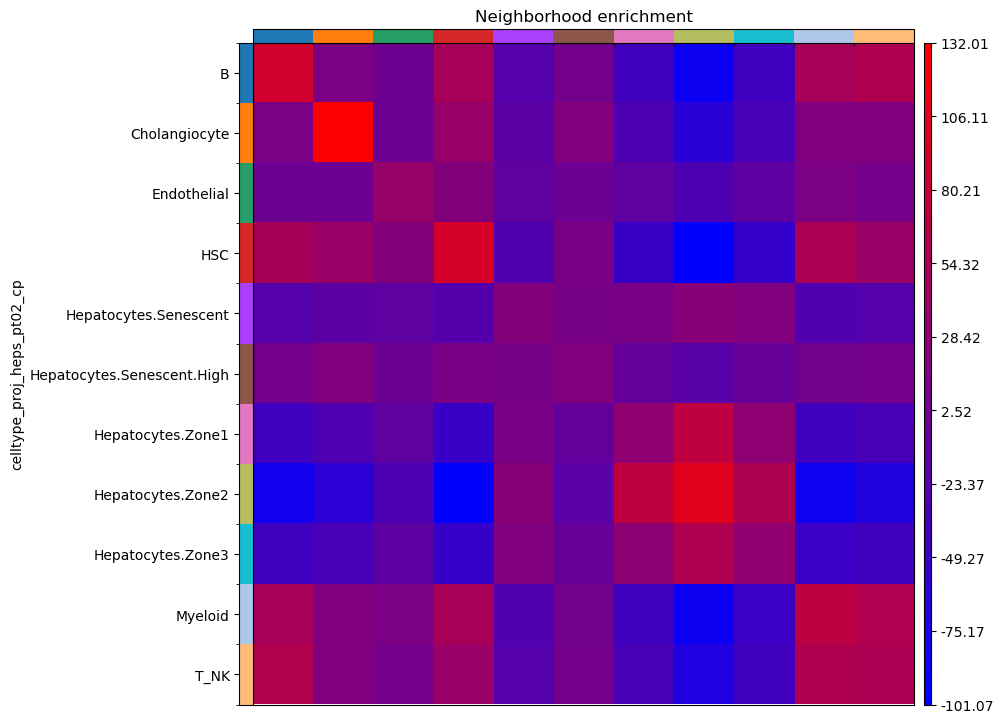

In [13]:
# Define a colormap transitioning directly from blue to red
custom_cmap = LinearSegmentedColormap.from_list("custom_red_blue", ["blue", "red"])

# Plot neighborhood enrichment with the custom colormap
sq.pl.nhood_enrichment(
    adata_sub, 
    cluster_key="celltype_proj_heps_pt02_cp",
    cmap=custom_cmap
)

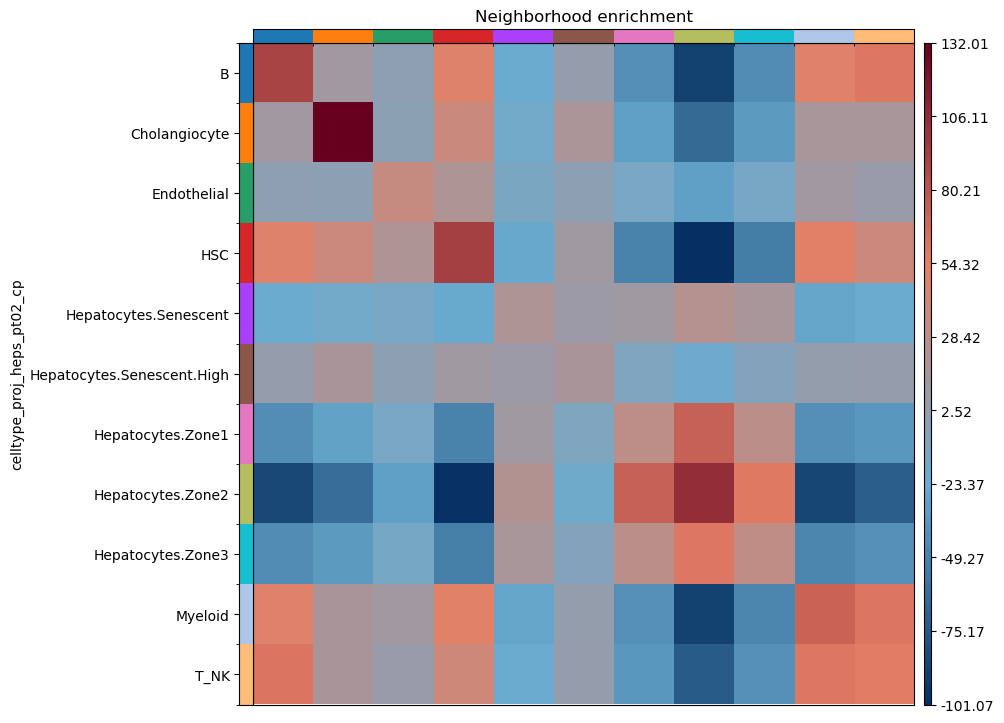

In [54]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import squidpy as sq

# Get the original "RdBu_r" colormap
original_cmap = plt.get_cmap("RdBu_r")

# Extract red and blue while skipping the white midpoint
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_rdblue",
    [original_cmap(0.0),  # Strong Blue
     original_cmap(0.25), # Lighter Blue
     original_cmap(0.75), # Lighter Red
     original_cmap(1.0)]  # Strong Red
)

# Plot neighborhood enrichment with the custom colormap
sq.pl.nhood_enrichment(
    adata_sub, 
    cluster_key="celltype_proj_heps_pt02_cp",
    cmap=custom_cmap
)

plt.savefig(outdir + 'enrich_mat_sub_red_blue.pdf', bbox_inches='tight')


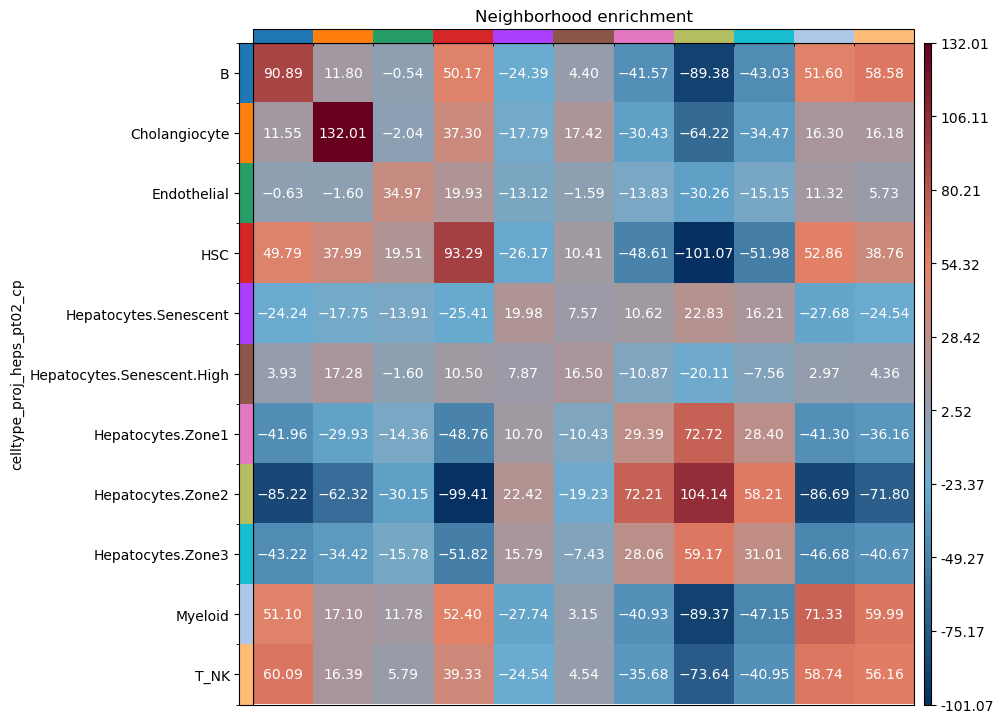

In [55]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import squidpy as sq

# Get the original "RdBu_r" colormap
original_cmap = plt.get_cmap("RdBu_r")

# Extract red and blue while skipping the white midpoint
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_rdblue",
    [original_cmap(0.0),  # Strong Blue
     original_cmap(0.25), # Lighter Blue
     original_cmap(0.75), # Lighter Red
     original_cmap(1.0)]  # Strong Red
)

# Plot neighborhood enrichment with the custom colormap
sq.pl.nhood_enrichment(
    adata_sub, 
    cluster_key="celltype_proj_heps_pt02_cp",
    cmap=custom_cmap,
    annotate = True
)

plt.savefig(outdir + 'enrich_mat_sub_red_blue_anno.pdf', bbox_inches='tight')


In [5]:
from squidpy.gr._utils import (
    _assert_categorical_obs,
    _assert_non_empty_sequence)

In [6]:
from __future__ import annotations

from collections.abc import Mapping, Sequence
from pathlib import Path
from types import MappingProxyType
from typing import TYPE_CHECKING, Any, Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from anndata import AnnData
from matplotlib.axes import Axes

from squidpy._constants._constants import RipleyStat
from squidpy._constants._pkg_constants import Key
from squidpy._docs import d
from squidpy.gr._utils import (
    _assert_categorical_obs,
    _assert_non_empty_sequence,
    _get_valid_values,
)
from squidpy.pl._color_utils import Palette_t, _get_palette, _maybe_set_colors
from squidpy.pl._utils import _heatmap, save_fig

In [7]:
def _get_data(adata: AnnData, cluster_key: str, func_name: str, attr: str = "uns", **kwargs: Any) -> Any:
    key = getattr(Key.uns, func_name)(cluster_key, **kwargs)

    try:
        if attr == "uns":
            return adata.uns[key]
        elif attr == "obsm":
            return adata.obsm[key]
        else:
            raise ValueError(f"attr must be either 'uns' or 'obsm', got {attr}")
    except KeyError:
        raise KeyError(
            f"Unable to get the data from `adata.uns[{key!r}]`. "
            f"Please run `squidpy.gr.{func_name}(..., cluster_key={cluster_key!r})` first."
        ) from None


In [8]:
_assert_categorical_obs(adata_sub, key="celltype_proj_heps_pt02_cp")
array = _get_data(adata_sub, cluster_key="celltype_proj_heps_pt02_cp", func_name="nhood_enrichment")["zscore"]

In [9]:
array[5].tolist()

[3.930621131438231,
 17.280255583773478,
 -1.59821137202234,
 10.501061582847763,
 7.870547025036997,
 16.502011393407056,
 -10.873875945367288,
 -20.110605173524196,
 -7.559882006313066,
 2.974482947326262,
 4.357880206225591]

In [10]:
sen_high_row = array[5].tolist()

In [11]:
len(array)

11

In [12]:
ct_sort = adata_sub.obs["celltype_proj_heps_pt02_cp"].unique().tolist()

In [13]:
ct_sort

['Hepatocytes.Zone2',
 'Hepatocytes.Zone3',
 'B',
 'Endothelial',
 'Myeloid',
 'Cholangiocyte',
 'HSC',
 'T_NK',
 'Hepatocytes.Senescent.High',
 'Hepatocytes.Senescent',
 'Hepatocytes.Zone1']

In [14]:
ct_sort.sort()

In [15]:
ct_sort

['B',
 'Cholangiocyte',
 'Endothelial',
 'HSC',
 'Hepatocytes.Senescent',
 'Hepatocytes.Senescent.High',
 'Hepatocytes.Zone1',
 'Hepatocytes.Zone2',
 'Hepatocytes.Zone3',
 'Myeloid',
 'T_NK']

In [16]:
# Extract 5th element from each row
fifth_elements = [row[5] for row in array]

print(fifth_elements)  # Output: [5, 10, 15, 20, 25]

[4.395122472386456, 17.42076831401678, -1.5851781831555878, 10.414993491117364, 7.566314062979406, 16.502011393407056, -10.43325770832384, -19.232264614285448, -7.434504437486336, 3.150789988613527, 4.537416763819769]


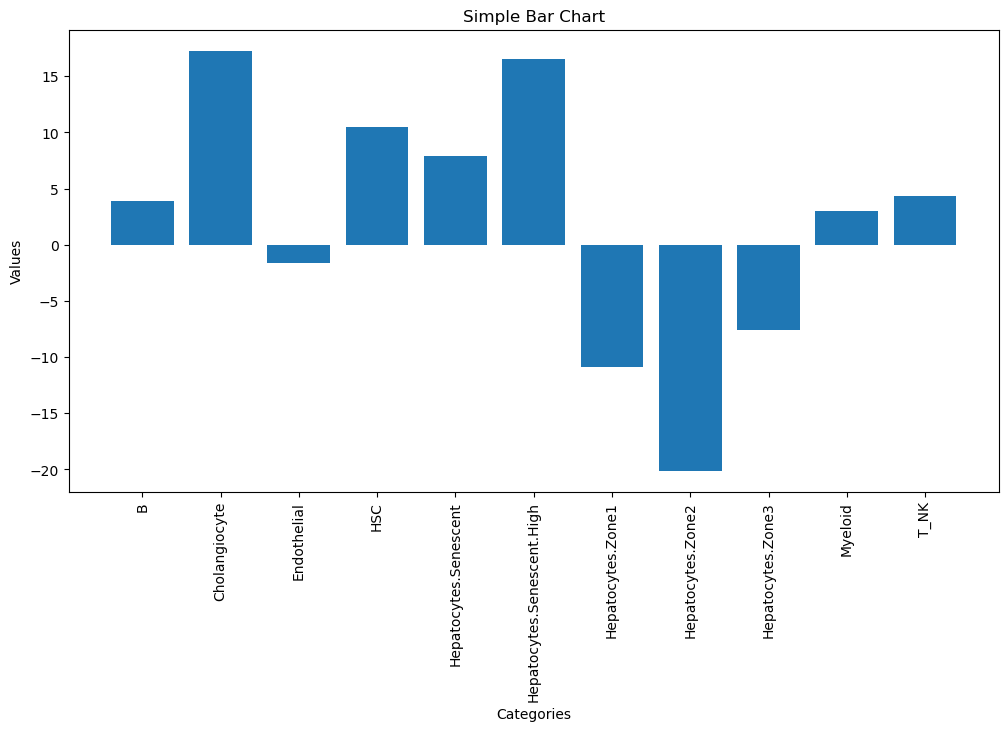

In [17]:
# Example list of values
#values = [10, 20, 30, 40, 50]
labels = ['A', 'B', 'C', 'D', 'E']  # Optional: labels for each bar

plt.figure(figsize=(12, 6))
# Create the bar chart
plt.bar(ct_sort,sen_high_row )

# Add labels and title
plt.xlabel('Categories')
plt.ylabel('Values')
plt.title('Simple Bar Chart')

# Show the plot
plt.xticks(rotation=90)

plt.show()


In [18]:
array

array([[  90.8866522 ,   11.80125976,   -0.54160172,   50.16908492,
         -24.39207193,    4.39512247,  -41.57192948,  -89.37711325,
         -43.03023447,   51.60174925,   58.58111443],
       [  11.55116193,  132.00818058,   -2.04097222,   37.2974543 ,
         -17.79152398,   17.42076831,  -30.43110038,  -64.2239365 ,
         -34.46878372,   16.29604874,   16.18022858],
       [  -0.63473269,   -1.59742266,   34.96864346,   19.93297609,
         -13.11632354,   -1.58517818,  -13.82794998,  -30.26433243,
         -15.14504382,   11.32418792,    5.72645006],
       [  49.79197313,   37.99251577,   19.50683762,   93.28767062,
         -26.16759781,   10.41499349,  -48.6076028 , -101.06573586,
         -51.97545551,   52.86238303,   38.75757339],
       [ -24.24280719,  -17.74758203,  -13.90991668,  -25.41234152,
          19.97789516,    7.56631406,   10.62312859,   22.83045418,
          16.20542909,  -27.67550689,  -24.53545656],
       [   3.93062113,   17.28025558,   -1.5982113

In [19]:
adata_sub

AnnData object with n_obs × n_vars = 270311 × 17931
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'celltype_proj_heps_pt02', 'celltype_proj_heps_pt02_cp'
    uns: 'celltype_proj_colors', 'celltype_proj_heps_pt02_cp_co_occurrence', 'celltype_proj_heps_pt02_cp_nhood_enrichment', 'clusters', 'hvg', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [90]:
cluster_key

NameError: name 'cluster_key' is not defined

In [20]:
from squidpy.pl._utils import _heatmap, save_fig


In [21]:
array

array([[  90.8866522 ,   11.80125976,   -0.54160172,   50.16908492,
         -24.39207193,    4.39512247,  -41.57192948,  -89.37711325,
         -43.03023447,   51.60174925,   58.58111443],
       [  11.55116193,  132.00818058,   -2.04097222,   37.2974543 ,
         -17.79152398,   17.42076831,  -30.43110038,  -64.2239365 ,
         -34.46878372,   16.29604874,   16.18022858],
       [  -0.63473269,   -1.59742266,   34.96864346,   19.93297609,
         -13.11632354,   -1.58517818,  -13.82794998,  -30.26433243,
         -15.14504382,   11.32418792,    5.72645006],
       [  49.79197313,   37.99251577,   19.50683762,   93.28767062,
         -26.16759781,   10.41499349,  -48.6076028 , -101.06573586,
         -51.97545551,   52.86238303,   38.75757339],
       [ -24.24280719,  -17.74758203,  -13.90991668,  -25.41234152,
          19.97789516,    7.56631406,   10.62312859,   22.83045418,
          16.20542909,  -27.67550689,  -24.53545656],
       [   3.93062113,   17.28025558,   -1.5982113

In [103]:
cluster_key = 'celltype_proj_heps_pt02_cp'
ad = AnnData(X=array, obs={cluster_key: pd.Categorical(adata_sub.obs[cluster_key].cat.categories)})


In [104]:
_maybe_set_colors(source=adata_sub, target=ad, key=cluster_key, palette=None)

ValueError: setting an array element with a sequence.

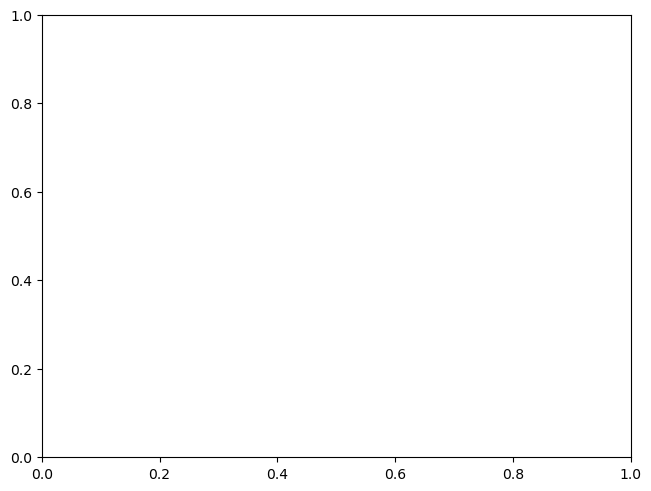

In [107]:
 fig = _heatmap(
        adata_sub, 
        key="celltype_proj_heps_pt02_cp",
        #key=cluster_key,
        #title=title,
        method="zscore",
        cont_cmap="viridis",
        #annotate=annotate,
        #figsize=(2 * ad.n_obs // 3, 2 * ad.n_obs // 3) if figsize is None else figsize,
        #dpi=dpi,
        #cbar_kwargs=cbar_kwargs,
        #ax=ax,
        #**kwargs,
    )

In [ ]:
 mode: Literal["zscore", "count"] = "zscore",
    annotate: bool = False,
    method: str | None = None,
    title: str | None = None,
    cmap: str = "viridis",
    palette: Palette_t = None,
    cbar_kwargs: Mapping[str, Any] = MappingProxyType({}),
    figsize: tuple[float, float] | None = None,
    dpi: int | None = None,
    save: str | Path | None = None,
    ax: Axes | None = None,

In [97]:
adata_sub_sen_high =  adata_sub[adata_sub.obs['celltype_proj_heps_pt02_cp'].isin(['Hepatocytes.Senescent.High'])]

In [98]:
adata_sub_sen_high

View of AnnData object with n_obs × n_vars = 1868 × 17931
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'celltype_proj_heps_pt02', 'celltype_proj_heps_pt02_cp'
    uns: 'celltype_proj_colors', 'celltype_proj_heps_pt02_cp_co_occurrence', 'celltype_proj_heps_pt02_cp_nhood_enrichment', 'clusters', 'hvg', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'
    obsp: 'spatial_connectivities', 'spatial_distances'

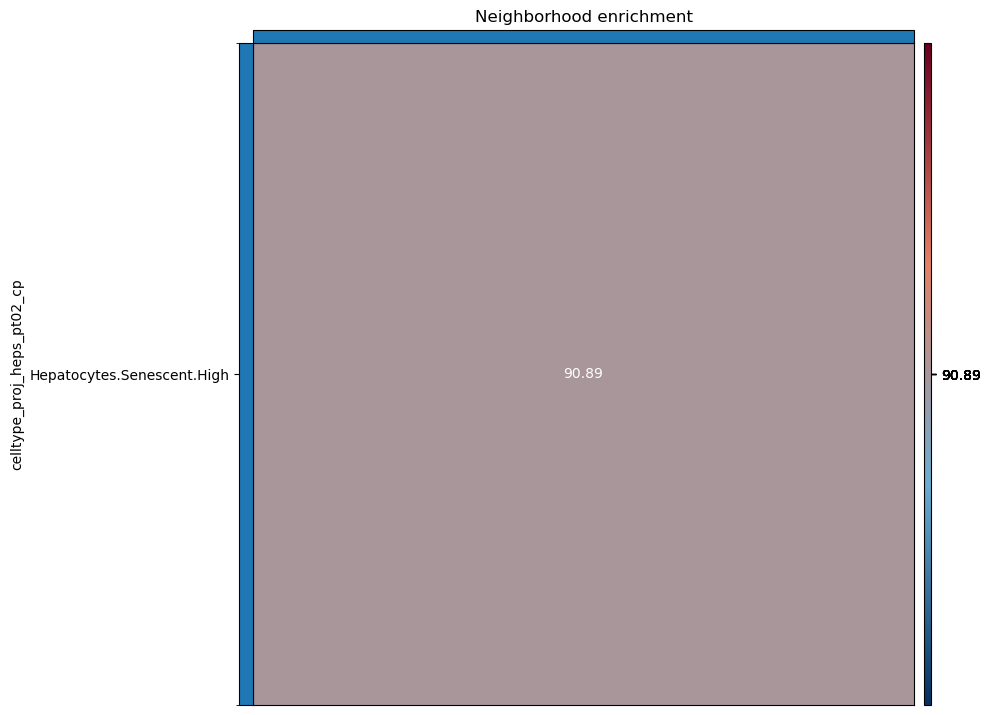

In [100]:
sq.pl.nhood_enrichment(
    adata_sub_sen_high, 
    cluster_key="celltype_proj_heps_pt02_cp",
    cmap=custom_cmap,
    annotate = True
)

0      3.930621
1     17.280256
2     -1.598211
3     10.501062
4      7.870547
5     16.502011
6    -10.873876
7    -20.110605
8     -7.559882
9      2.974483
10     4.357880
Name: 5, dtype: float64


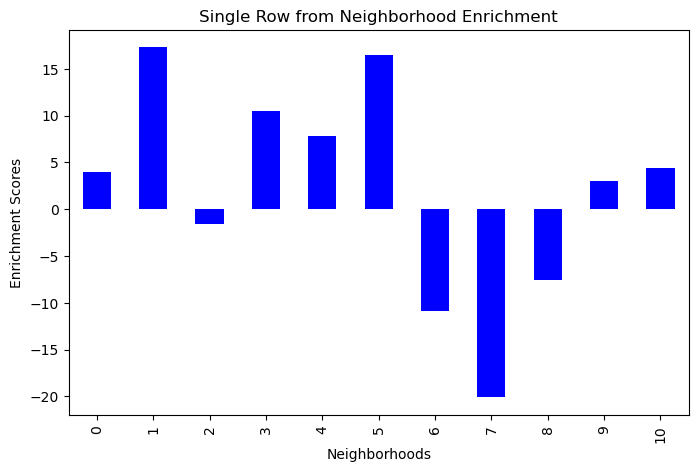

In [117]:
#sq.pl.nhood_enrichment(adata, show=False)  # show=False so we can manipulate the data first

# Extract the enrichment data
enrichment_data = adata_sub.uns['celltype_proj_heps_pt02_cp_nhood_enrichment']['zscore']

# Let's say we want to plot the first row (row index 0)
# You can select a row using numpy indexing or pandas
import pandas as pd

# Convert the enrichment data to a DataFrame if it's not already
enrichment_df = pd.DataFrame(enrichment_data)

# Select a single row (for example, the first row)
row_to_plot = enrichment_df.iloc[5]  # Select the first row
print(row_to_plot )
# Plot this row
plt.figure(figsize=(8, 5))
row_to_plot.plot(kind='bar', color='blue')
plt.title("Single Row from Neighborhood Enrichment")
plt.xlabel("Neighborhoods")
plt.ylabel("Enrichment Scores")
plt.show()

In [48]:
heps_labels = ['Hepatocytes.Senescent.High', 'Hepatocytes.Senescent', 'Hepatocytes.Zone1', 'Hepatocytes.Zone2',
        'Hepatocytes.Zone3']

In [44]:
rows_to_plot_values

array([[-24.24280719, -17.74758203, -13.90991668, -25.41234152,
         19.97789516,   7.56631406,  10.62312859,  22.83045418,
         16.20542909, -27.67550689, -24.53545656],
       [  3.93062113,  17.28025558,  -1.59821137,  10.50106158,
          7.87054703,  16.50201139, -10.87387595, -20.11060517,
         -7.55988201,   2.97448295,   4.35788021],
       [-41.95712257, -29.9329645 , -14.35536966, -48.76137357,
         10.70223212, -10.43325771,  29.39202361,  72.71793677,
         28.39766645, -41.29772978, -36.16061828],
       [-85.22055098, -62.31770529, -30.15036916, -99.41014242,
         22.42201917, -19.23226461,  72.21401693, 104.13761972,
         58.205599  , -86.69102243, -71.80134903],
       [-43.22094448, -34.42399281, -15.77816477, -51.82215434,
         15.79027425,  -7.43450444,  28.06143954,  59.16952719,
         31.00603907, -46.67605772, -40.66577216]])

In [ ]:
# reordering sen.high to be on top

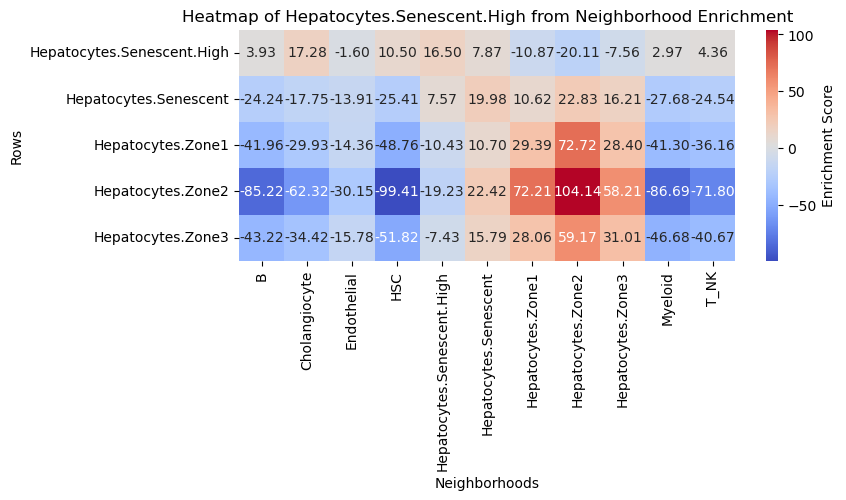

In [60]:
# Extract the enrichment data
enrichment_data = adata_sub.uns['celltype_proj_heps_pt02_cp_nhood_enrichment']['zscore']

# Let's say we want to plot the first row (row index 0)
# You can select a row using numpy indexing or pandas
import pandas as pd

# Convert the enrichment data to a DataFrame if it's not already
enrichment_df = pd.DataFrame(enrichment_data)

# Select a single row (for example, the first row)
rows_to_plot = enrichment_df.iloc[4:9]  # Select the first row
rows_to_plot = rows_to_plot.reindex([5, 4, 6, 7, 8])

# Reorder columns: Swap the 5th and 6th columns
col_indices = list(range(enrichment_df.shape[1]))  # Get all column indices
col_indices[4], col_indices[5] = col_indices[5], col_indices[4]  # Swap columns 5 and 6
rows_to_plot = rows_to_plot.iloc[:, col_indices]  # Reorder columns


rows_to_plot_values = rows_to_plot.values

# Plot the rows as a heatmap
plt.figure(figsize=(8, 3))  # Adjust height to fit multiple rows
sns.heatmap(rows_to_plot_values, cmap='coolwarm', fmt='.2f', annot=True, 
            xticklabels=[ct_sort[i] for i in col_indices], yticklabels=heps_labels, 
            cbar_kws={'label': 'Enrichment Score'})

# Add title and labels
plt.title("Heatmap of Hepatocytes.Senescent.High from Neighborhood Enrichment")
plt.xlabel("Neighborhoods")
plt.ylabel("Rows")
# Show the plot
plt.xticks(rotation=90)
#plt.yticks(rotation=90)


#plt.show()
plt.savefig(outdir + 'enrich_mat_sub_anno_red_blue_only_high_sen_all_heps.pdf', bbox_inches='tight')


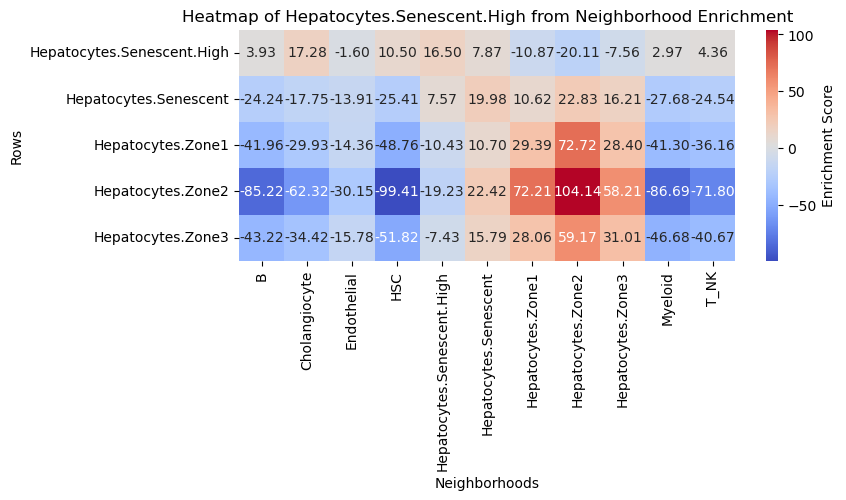

In [56]:
# Extract the enrichment data
enrichment_data = adata_sub.uns['celltype_proj_heps_pt02_cp_nhood_enrichment']['zscore']

# Let's say we want to plot the first row (row index 0)
# You can select a row using numpy indexing or pandas
import pandas as pd

# Convert the enrichment data to a DataFrame if it's not already
enrichment_df = pd.DataFrame(enrichment_data)

# Select a single row (for example, the first row)
rows_to_plot = enrichment_df.iloc[4:9]  # Select the first row
rows_to_plot = rows_to_plot.reindex([5, 4, 6, 7, 8])

# Reorder columns: Swap the 5th and 6th columns
col_indices = list(range(enrichment_df.shape[1]))  # Get all column indices
col_indices[4], col_indices[5] = col_indices[5], col_indices[4]  # Swap columns 5 and 6
rows_to_plot = rows_to_plot.iloc[:, col_indices]  # Reorder columns


rows_to_plot_values = rows_to_plot.values

# Plot the rows as a heatmap
plt.figure(figsize=(8, 3))  # Adjust height to fit multiple rows
sns.heatmap(rows_to_plot_values, cmap='coolwarm', fmt='.2f', annot=False, 
            xticklabels=[ct_sort[i] for i in col_indices], yticklabels=heps_labels, 
            cbar_kws={'label': 'Enrichment Score'})

# Add title and labels
plt.title("Heatmap of Hepatocytes.Senescent.High from Neighborhood Enrichment")
plt.xlabel("Neighborhoods")
plt.ylabel("Rows")
# Show the plot
plt.xticks(rotation=90)
#plt.yticks(rotation=90)


#plt.show()
plt.savefig(outdir + 'enrich_mat_sub_red_blue_only_high_sen_all_heps.pdf', bbox_inches='tight')


In [28]:
enrichment_df.iloc[5:8]

,0,1,2,3,4,5,6,7,8,9,10
5,3.930621,17.280256,-1.598211,10.501062,7.870547,16.502011,-10.873876,-20.110605,-7.559882,2.974483,4.357880
6,-41.957123,-29.932964,-14.355370,-48.761374,10.702232,-10.433258,29.392024,72.717937,28.397666,-41.297730,-36.160618
7,-85.220551,-62.317705,-30.150369,-99.410142,22.422019,-19.232265,72.214017,104.137620,58.205599,-86.691022,-71.801349


In [123]:
outdir


'/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/neighborhood_analysis/high_score_sen_cells_pt02/'

In [120]:
row_to_plot_reshaped

array([[  3.93062113,  17.28025558,  -1.59821137,  10.50106158,
          7.87054703,  16.50201139, -10.87387595, -20.11060517,
         -7.55988201,   2.97448295,   4.35788021]])

In [114]:
enrichment_data 

{'count': array([[  7319,   2532,   3889,   5983,   3862,    427,   2097,   6325,
           2883,   7322,   4381],
        [  2517,  10902,   4111,   5633,   4853,    707,   3308,  10054,
           3998,   5572,   2747],
        [  3884,   4138,  12369,   8359,  10550,    689,   9127,  28703,
          11237,   9768,   4252],
        [  5992,   5671,   8337,  14979,   7363,    858,   4167,  12557,
           5580,  11608,   5428],
        [  3849,   4847,  10476,   7392,  20541,   1281,  16397,  52943,
          20696,   9736,   3973],
        [   419,    705,    689,    855,   1291,    255,    616,   2008,
            893,    860,    425],
        [  2073,   3359,   9082,   4145,  16392,    627,  17694,  55563,
          19863,   6927,   2501],
        [  6307,  10049,  28623,  12510,  52895,   2022,  55574, 181516,
          64133,  21240,   7815],
        [  2877,   3981,  11162,   5592,  20646,    894,  19795,  64069,
          25749,   8859,   3116],
        [  7323,   5617,   9

In [111]:
adata_sub

AnnData object with n_obs × n_vars = 270311 × 17931
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'celltype_proj_heps_pt02', 'celltype_proj_heps_pt02_cp'
    uns: 'celltype_proj_colors', 'celltype_proj_heps_pt02_cp_co_occurrence', 'celltype_proj_heps_pt02_cp_nhood_enrichment', 'clusters', 'hvg', 'neighbors', 'pca', 'spatial', 'spatial_neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'
    obsp: 'spatial_connectivities', 'spatial_distances'